# 01 — Generate a fully synthetic annual default-count dataset

This notebook creates a **fully synthetic** annual dataset with the same basic schema used by the empirical analysis:

`Year, ALL, D_ALL, SG, D_SG, IG, D_IG`

The generated file covers **1920–2023 (104 years)**.

## Important

- No Moody's raw data are read or embedded in this notebook.
- The generated counts are **not intended to reproduce the empirical observations** reported in the paper.
- The synthetic data are provided only so that the public computational workflow can be inspected and executed without access to proprietary data.
- Portfolio sizes are held fixed at representative values of the same order as those used in the paper.
- Default counts are generated from persistent latent annual credit conditions with a common component shared by SG and IG.

The output file is:

`data/M_1920_2023.csv`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Configuration

The seed is fixed for exact reproducibility.

The synthetic portfolio sizes are constant:

- SG: 1008 obligors
- IG: 1565 obligors
- ALL: 2573 obligors

The baseline synthetic default rates are chosen only to give default counts of roughly the same order of magnitude as the empirical application. They are **not fitted to the proprietary data**.


In [2]:
SEED = 12345
rng = np.random.default_rng(SEED)

START_YEAR = 1920
END_YEAR = 2023
YEARS = np.arange(START_YEAR, END_YEAR + 1)
T = len(YEARS)

N_SG = 1008
N_IG = 1565
N_ALL = N_SG + N_IG

# Synthetic baseline annual default probabilities.
BASE_P_SG = 0.0340
BASE_P_IG = 0.0012

# Common annual credit-state persistence.
PHI_COMMON = 0.78

# Sector-specific persistent deviations.
PHI_SG = 0.45
PHI_IG = 0.35
SIGMA_SG = 0.22
SIGMA_IG = 0.28

# Sensitivity of each rating class to the common latent state.
BETA_SG = 0.65
BETA_IG = 0.80

print(f"Number of years: {T}")
print(f"Portfolio sizes: ALL={N_ALL}, SG={N_SG}, IG={N_IG}")


Number of years: 104
Portfolio sizes: ALL=2573, SG=1008, IG=1565


## 2. Persistent latent annual credit conditions

A stationary AR(1) common state is used only to create persistent clustering in the synthetic counts.

Sector-specific AR(1) deviations add class-specific variation.


In [3]:
def simulate_stationary_ar1(rng, n, phi, innovation_sd):
    # Simulate a zero-mean stationary AR(1) process.
    x = np.empty(n, dtype=float)
    stationary_sd = innovation_sd / np.sqrt(1.0 - phi**2)
    x[0] = rng.normal(0.0, stationary_sd)

    for t in range(1, n):
        x[t] = phi * x[t - 1] + rng.normal(0.0, innovation_sd)

    return x


def logit(p):
    p = np.asarray(p, dtype=float)
    return np.log(p / (1.0 - p))


def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))


# Choose the innovation scale so that the stationary variance
# of the common state is approximately one.
COMMON_INNOV_SD = np.sqrt(1.0 - PHI_COMMON**2)

common_state = simulate_stationary_ar1(
    rng=rng,
    n=T,
    phi=PHI_COMMON,
    innovation_sd=COMMON_INNOV_SD,
)

sg_specific = simulate_stationary_ar1(
    rng=rng,
    n=T,
    phi=PHI_SG,
    innovation_sd=SIGMA_SG,
)

ig_specific = simulate_stationary_ar1(
    rng=rng,
    n=T,
    phi=PHI_IG,
    innovation_sd=SIGMA_IG,
)


## 3. Synthetic annual default probabilities and counts

The common latent state affects both SG and IG, producing persistent co-movement.

Conditional on the latent annual probabilities, SG and IG default counts are drawn independently from Binomial distributions. The ALL series is constructed exactly as the sum of the two classes.


In [4]:
eta_sg = logit(BASE_P_SG) + BETA_SG * common_state + sg_specific
eta_ig = logit(BASE_P_IG) + BETA_IG * common_state + ig_specific

p_sg = logistic(eta_sg)
p_ig = logistic(eta_ig)

D_SG = rng.binomial(N_SG, p_sg)
D_IG = rng.binomial(N_IG, p_ig)
D_ALL = D_SG + D_IG

df = pd.DataFrame({
    "Year": YEARS,
    "ALL": N_ALL,
    "D_ALL": D_ALL,
    "SG": N_SG,
    "D_SG": D_SG,
    "IG": N_IG,
    "D_IG": D_IG,
})

df.head()


,Year,ALL,D_ALL,SG,D_SG,IG,D_IG
0,1920,2573,13,1008,13,1565,0
1,1921,2573,15,1008,11,1565,4
2,1922,2573,17,1008,16,1565,1
3,1923,2573,22,1008,20,1565,2
4,1924,2573,21,1008,21,1565,0


## 4. Save the synthetic CSV

The column names and annual span match the schema expected by the public analysis workflow.


In [8]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = DATA_DIR / "M_1920_2023_synthetic.csv"
df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved synthetic dataset to: {OUTPUT_CSV.resolve()}")


Saved synthetic dataset to: ./data/M_1920_2023_synthetic.csv


## 5. Integrity checks

These checks ensure that the synthetic file has the intended schema and internally consistent counts.


In [9]:
EXPECTED_COLUMNS = [
    "Year",
    "ALL",
    "D_ALL",
    "SG",
    "D_SG",
    "IG",
    "D_IG",
]

assert list(df.columns) == EXPECTED_COLUMNS
assert len(df) == 104
assert df["Year"].iloc[0] == 1920
assert df["Year"].iloc[-1] == 2023

assert (df["ALL"] == N_ALL).all()
assert (df["SG"] == N_SG).all()
assert (df["IG"] == N_IG).all()

assert (df["ALL"] == df["SG"] + df["IG"]).all()
assert (df["D_ALL"] == df["D_SG"] + df["D_IG"]).all()

assert ((df["D_SG"] >= 0) & (df["D_SG"] <= df["SG"])).all()
assert ((df["D_IG"] >= 0) & (df["D_IG"] <= df["IG"])).all()
assert ((df["D_ALL"] >= 0) & (df["D_ALL"] <= df["ALL"])).all()

print("All integrity checks passed.")


All integrity checks passed.


## 6. Quick summary

The precise values below are properties of this synthetic realization only. They should not be compared numerically with the empirical tables in the paper.


In [10]:
summary = pd.DataFrame({
    "Class": ["ALL", "SG", "IG"],
    "Mean obligors": [
        df["ALL"].mean(),
        df["SG"].mean(),
        df["IG"].mean(),
    ],
    "Mean defaults": [
        df["D_ALL"].mean(),
        df["D_SG"].mean(),
        df["D_IG"].mean(),
    ],
    "Mean synthetic default rate": [
        (df["D_ALL"] / df["ALL"]).mean(),
        (df["D_SG"] / df["SG"]).mean(),
        (df["D_IG"] / df["IG"]).mean(),
    ],
})

summary


,Class,Mean obligors,Mean defaults,Mean synthetic default rate
0,ALL,2573.0,40.788462,0.015852
1,SG,1008.0,38.634615,0.038328
2,IG,1565.0,2.153846,0.001376


## 7. Optional visual check

This plot is only a diagnostic for the synthetic series.


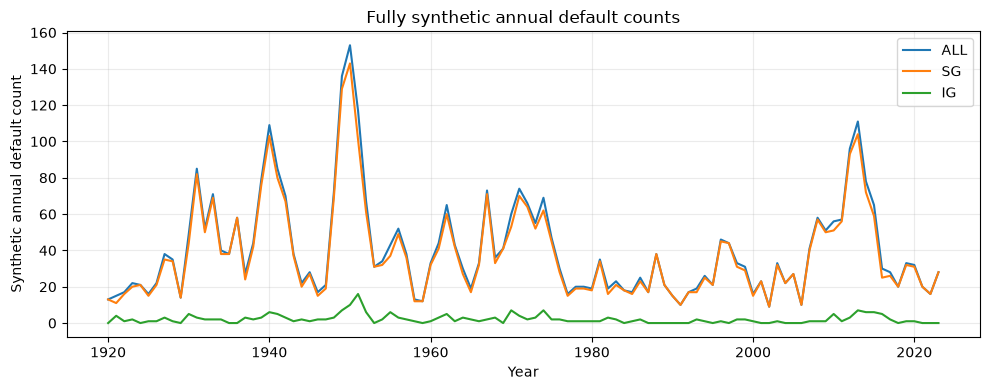

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["Year"], df["D_ALL"], label="ALL")
ax.plot(df["Year"], df["D_SG"], label="SG")
ax.plot(df["Year"], df["D_IG"], label="IG")

ax.set_xlabel("Year")
ax.set_ylabel("Synthetic annual default count")
ax.set_title("Fully synthetic annual default counts")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## Reproducibility note for the public repository

The empirical results in the manuscript were obtained from proprietary Moody's data and cannot be reproduced numerically from this synthetic file.

This notebook instead provides a public, fully synthetic dataset with the same basic file schema and time span so that the code structure and computational workflow can be executed without distributing proprietary observations.
